# Taller XAI - Mantenimiento Predictivo Industrial

> **Unidad:** Ética, Sesgo y Calidad en el Aprendizaje Automático  
> **Técnicas:** SHAP · Coeficientes · Visualización de Árbol · Permutation Importance  
> **Dataset:** AI4I 2020 Predictive Maintenance (UCI)

---

## Tabla de Contenidos

1. [Configuración e Importaciones](#1)
2. [Carga y Exploración de Datos (EDA)](#2)
3. [Calidad de Datos y Detección de Sesgos](#3)
4. [Preprocesamiento y Balanceo (SMOTE)](#4)
5. [Entrenamiento de Modelos](#5)
6. [Evaluación Comparativa](#6)
7. [Técnicas XAI](#7)
   - 7.1 Coeficientes — Regresión Logística
   - 7.2 Visualización del Árbol de Decisión
   - 7.3 SHAP Values — Random Forest
   - 7.4 Permutation Feature Importance
8. [Explicaciones Individuales (Casos Concretos)](#8)
9. [Análisis Ético y Reflexión](#9)
10. [Conclusiones y Recomendaciones](#10)

---
## 1. Configuración e Importaciones <a id='1'></a>

In [29]:
# ─────────────────────────────────────────────────────
# Instalación de dependencias (ejecutar solo una vez)
# ─────────────────────────────────────────────────────
# !pip install -r ../requirements.txt

import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.join('..', 'src'))

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# XAI — Explicabilidad
import shap

# Serialización de modelos
import joblib

# Utilidades del proyecto
from utils import (
    set_style, evaluar_modelo, tabla_comparativa,
    plot_confusion_matrix, plot_roc_curves,
    plot_distribucion_objetivo, guardar_modelo
)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas
DATA_PATH    = os.path.join('..', 'data', 'ai4i_predictive_maintenance.csv')
FIG_PATH     = os.path.join('..', 'outputs', 'figures')
MODEL_PATH   = os.path.join('..', 'outputs', 'models')
REPORT_PATH  = os.path.join('..', 'outputs', 'reports')

os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)

set_style()
print('✅ Entorno configurado correctamente')
print(f'   Python  : {sys.version.split()[0]}')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   SHAP    : {shap.__version__}')

✅ Entorno configurado correctamente
   Python  : 3.12.4
   Pandas  : 2.2.2
   NumPy   : 2.4.6
   SHAP    : 0.51.0


---
## 2. Carga y Exploración de Datos (EDA) <a id='2'></a>

In [30]:
# ── Carga del dataset ──────────────────────────────────
df = pd.read_csv(DATA_PATH)

print('=' * 55)
print('  INFORMACIÓN GENERAL DEL DATASET')
print('=' * 55)
print(f'  Registros : {df.shape[0]:,}')
print(f'  Variables : {df.shape[1]}')
print()
df.info()

  INFORMACIÓN GENERAL DEL DATASET
  Registros : 10,000
  Variables : 8

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Type                     10000 non-null  object 
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 625.1+ KB


In [31]:
# ── Primeras filas ─────────────────────────────────────
df.head(10)

,UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,L,297.0,306.4,1678,27.8,120,0
1,2,H,297.7,307.4,1539,33.8,138,0
2,3,M,300.8,309.7,1655,21.3,242,0
3,4,L,297.7,306.8,1356,39.3,102,0
4,5,L,302.2,312.7,1563,45.9,88,0
5,6,L,299.9,310.0,1412,26.5,237,0
6,7,L,300.2,310.7,1319,40.2,102,0
7,8,M,299.4,309.7,1383,32.0,250,0
8,9,M,301.5,312.3,1440,46.7,23,0
9,10,M,301.6,312.4,1760,16.9,21,0


In [32]:
# ── Estadísticas descriptivas ──────────────────────────
df.describe().round(3)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.025,310.023,1534.011,40.110,125.473,0.034
std,2886.896,2.000,2.250,179.625,9.953,73.528,0.180
min,1.000,292.200,301.000,1000.000,3.000,0.000,0.000
25%,2500.750,298.700,308.500,1411.000,33.400,61.000,0.000
50%,5000.500,300.000,310.000,1534.000,40.100,126.000,0.000
75%,7500.250,301.400,311.600,1658.000,46.900,189.000,0.000
max,10000.000,309.000,320.500,2205.000,75.400,253.000,1.000


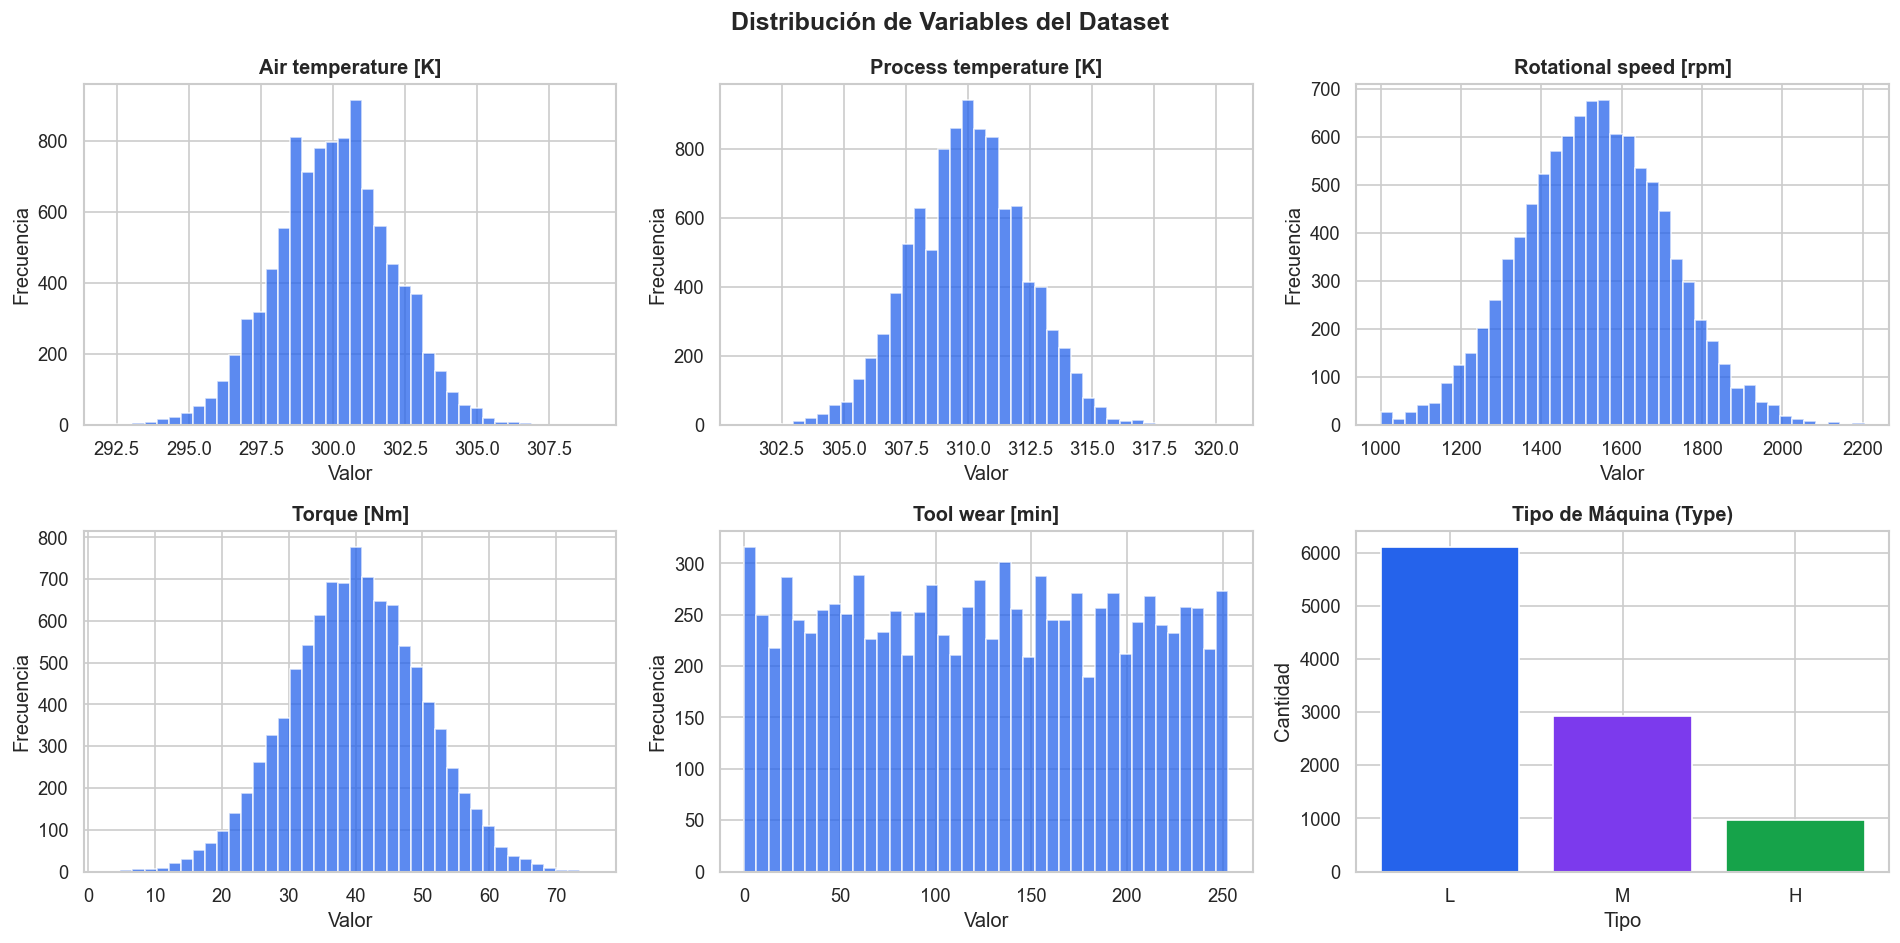

In [33]:
# ── Distribución de variables numéricas ────────────────
features_num = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features_num):
    axes[i].hist(df[col], bins=40, color='#2563EB', alpha=0.75, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Distribución de Type (variable categórica)
type_counts = df['Type'].value_counts()
axes[5].bar(type_counts.index, type_counts.values,
            color=['#2563EB','#7C3AED','#16A34A'], edgecolor='white')
axes[5].set_title('Tipo de Máquina (Type)', fontweight='bold')
axes[5].set_xlabel('Tipo')
axes[5].set_ylabel('Cantidad')

plt.suptitle('Distribución de Variables del Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '01_distribucion_variables.png'), bbox_inches='tight')
plt.show()

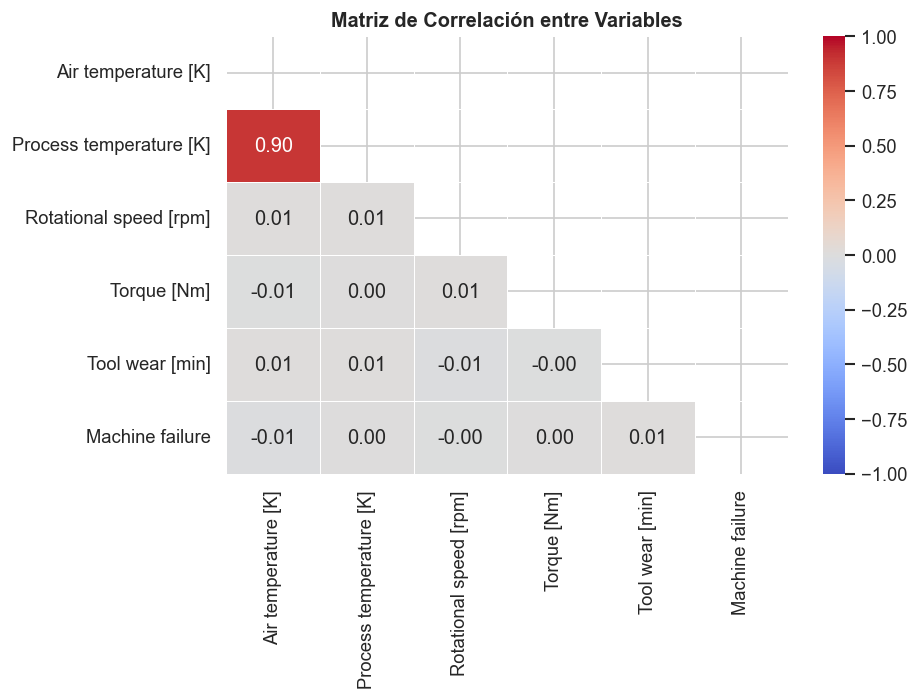

In [34]:
# ── Matriz de correlación ──────────────────────────────
df_num = df[features_num + ['Machine failure']]
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, center=0)
ax.set_title('Matriz de Correlación entre Variables', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '02_correlacion.png'), bbox_inches='tight')
plt.show()

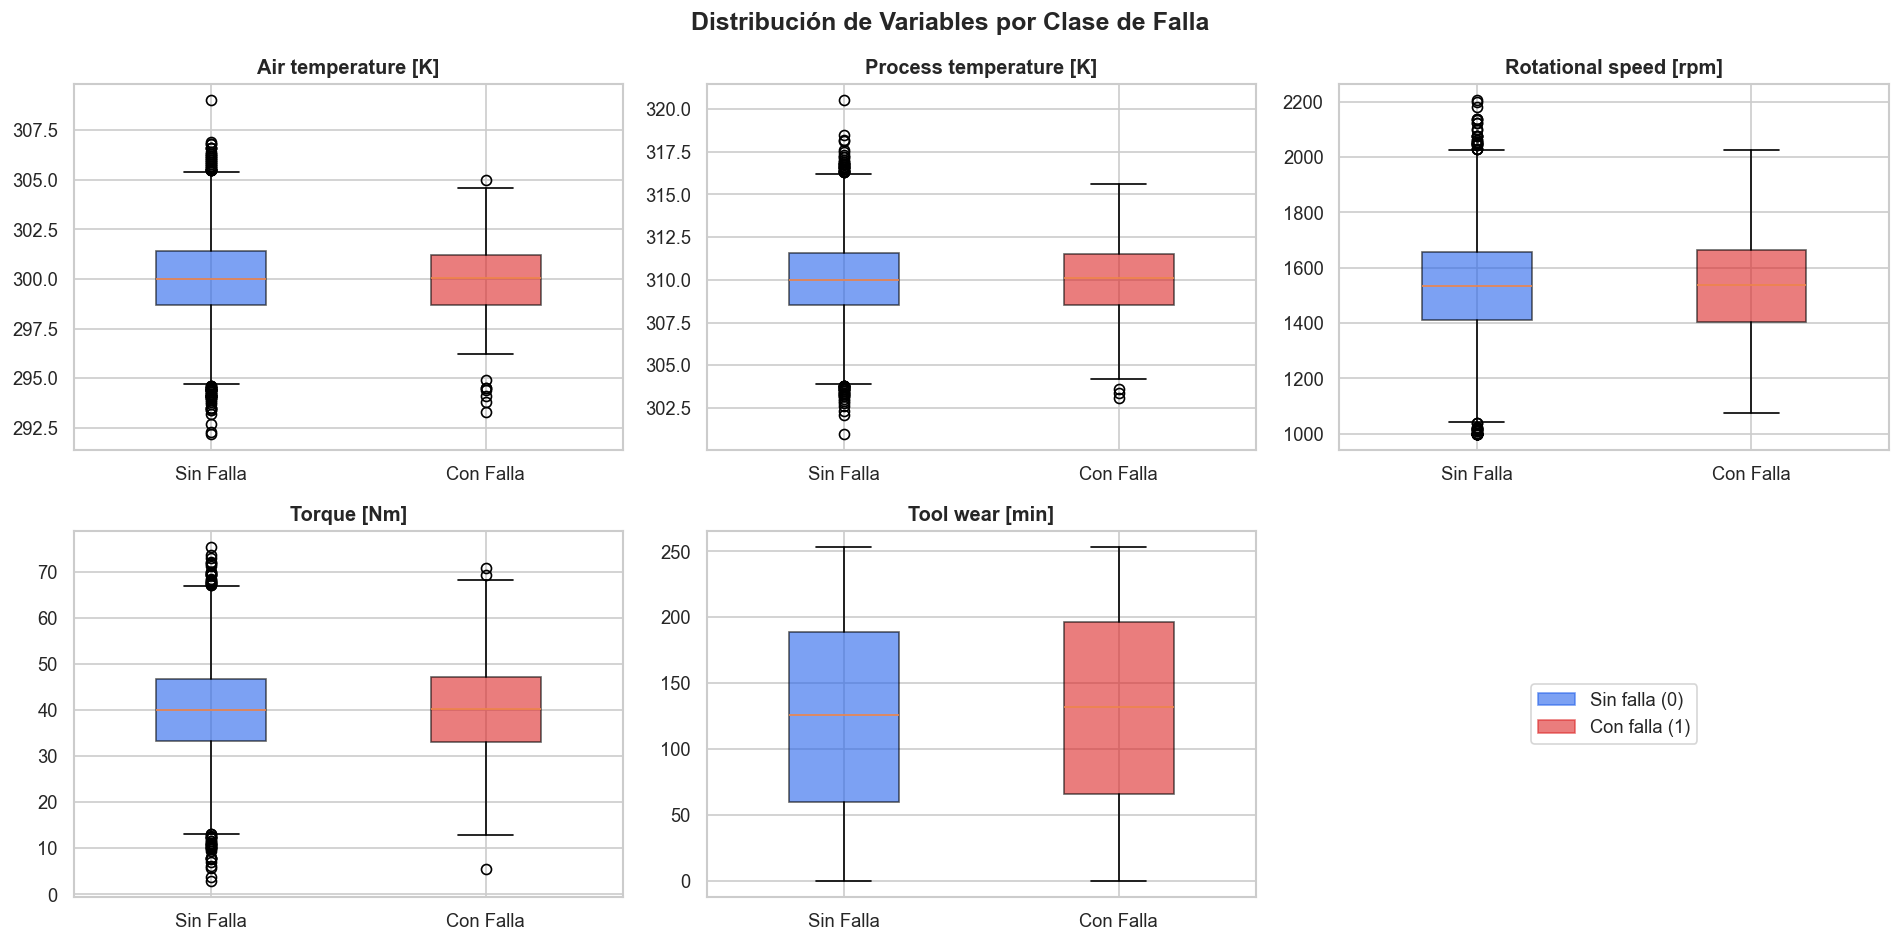

In [35]:
# ── Boxplots: Variables vs Falla ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colores = {0: '#2563EB', 1: '#DC2626'}

for i, col in enumerate(features_num):
    for label in [0, 1]:
        axes[i].boxplot(
            df[df['Machine failure'] == label][col],
            positions=[label],
            widths=0.4,
            patch_artist=True,
            boxprops=dict(facecolor=colores[label], alpha=0.6)
        )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sin Falla', 'Con Falla'])

sin_falla = mpatches.Patch(color='#2563EB', alpha=0.6, label='Sin falla (0)')
con_falla = mpatches.Patch(color='#DC2626', alpha=0.6, label='Con falla (1)')
axes[5].legend(handles=[sin_falla, con_falla], loc='center')
axes[5].axis('off')

plt.suptitle('Distribución de Variables por Clase de Falla', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '03_boxplots_por_clase.png'), bbox_inches='tight')
plt.show()

---
## 3. Calidad de Datos y Detección de Sesgos <a id='3'></a>

In [36]:
# ── Análisis de valores nulos ──────────────────────────
print('ANÁLISIS DE CALIDAD DE DATOS')
print('=' * 40)

nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
df_calidad = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
print(df_calidad)
print()
print(f'✅ Total de valores nulos: {nulos.sum()}')
print(f'✅ Duplicados: {df.duplicated().sum()}')

ANÁLISIS DE CALIDAD DE DATOS
                         Nulos  % Nulos
UDI                          0      0.0
Type                         0      0.0
Air temperature [K]          0      0.0
Process temperature [K]      0      0.0
Rotational speed [rpm]       0      0.0
Torque [Nm]                  0      0.0
Tool wear [min]              0      0.0
Machine failure              0      0.0

✅ Total de valores nulos: 0
✅ Duplicados: 0


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
  Sin falla (0): 9,664 registros (96.64%)
  Con falla (1): 336 registros (3.36%)

  ⚠️  Ratio de desbalance: 28.8:1
  → Se aplicará SMOTE para mitigar este sesgo.


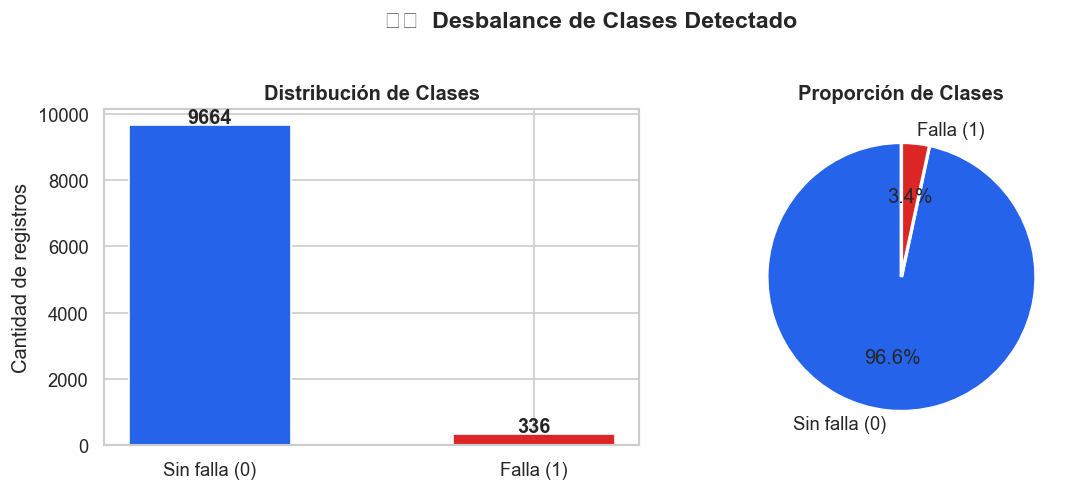

In [37]:
# ── Detección de desbalance (sesgo de clase) ───────────
print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO')
print('=' * 40)
conteo = df['Machine failure'].value_counts()
pct = (conteo / len(df) * 100).round(2)

for etiqueta, c, p in zip(['Sin falla (0)', 'Con falla (1)'], conteo.values, pct.values):
    print(f'  {etiqueta}: {c:,} registros ({p}%)')

ratio = conteo[0] / conteo[1]
print(f'\n  ⚠️  Ratio de desbalance: {ratio:.1f}:1')
print('  → Se aplicará SMOTE para mitigar este sesgo.')

plot_distribucion_objetivo(
    df['Machine failure'],
    save_path=os.path.join(FIG_PATH, '04_desbalance_clases.png')
)

TASA DE FALLA POR TIPO DE MÁQUINA
      Fallas  Total  Tasa de Falla
Type                              
H         32    961           3.33
L        193   6108           3.16
M        111   2931           3.79


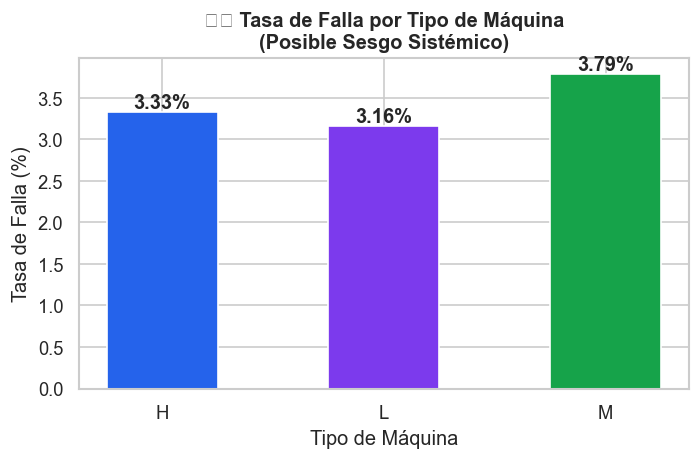

In [38]:
# ── Sesgo por tipo de máquina ──────────────────────────
print('TASA DE FALLA POR TIPO DE MÁQUINA')
print('=' * 40)
tasa_falla = df.groupby('Type')['Machine failure'].agg(['sum','count','mean'])
tasa_falla.columns = ['Fallas', 'Total', 'Tasa de Falla']
tasa_falla['Tasa de Falla'] = (tasa_falla['Tasa de Falla'] * 100).round(2)
print(tasa_falla)

fig, ax = plt.subplots(figsize=(6, 4))
colores = ['#2563EB', '#7C3AED', '#16A34A']
bars = ax.bar(tasa_falla.index, tasa_falla['Tasa de Falla'],
              color=colores, edgecolor='white', width=0.5)
for bar, val in zip(bars, tasa_falla['Tasa de Falla']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}%', ha='center', fontweight='bold')
ax.set_title('⚠️ Tasa de Falla por Tipo de Máquina\n(Posible Sesgo Sistémico)', fontweight='bold')
ax.set_xlabel('Tipo de Máquina')
ax.set_ylabel('Tasa de Falla (%)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '05_sesgo_tipo_maquina.png'), bbox_inches='tight')
plt.show()

---
## 4. Preprocesamiento y Balanceo (SMOTE) <a id='4'></a>

In [39]:
# ── Codificación y preparación de features ─────────────
df_proc = df.copy()

# Eliminar columna ID (no predictiva)
df_proc = df_proc.drop(columns=['UDI'])

# Codificación de variable categórica 'Type'
le = LabelEncoder()
df_proc['Type_enc'] = le.fit_transform(df_proc['Type'])
print('Mapeo Type → numérico:', dict(zip(le.classes_, le.transform(le.classes_))))

# Definir features y target
FEATURE_NAMES = [
    'Type_enc',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
TARGET = 'Machine failure'

X = df_proc[FEATURE_NAMES]
y = df_proc[TARGET]

# ── Split estratificado (70% train / 30% test) ─────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'\nTrain: {X_train.shape[0]:,} registros | Test: {X_test.shape[0]:,} registros')
print(f'Fallas en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Fallas en test : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Mapeo Type → numérico: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

Train: 7,000 registros | Test: 3,000 registros
Fallas en train: 235 (3.4%)
Fallas en test : 101 (3.4%)


DISTRIBUCIÓN TRAS SMOTE (Train):
  Sin falla (0): 6,765
  Con falla (1): 6,765


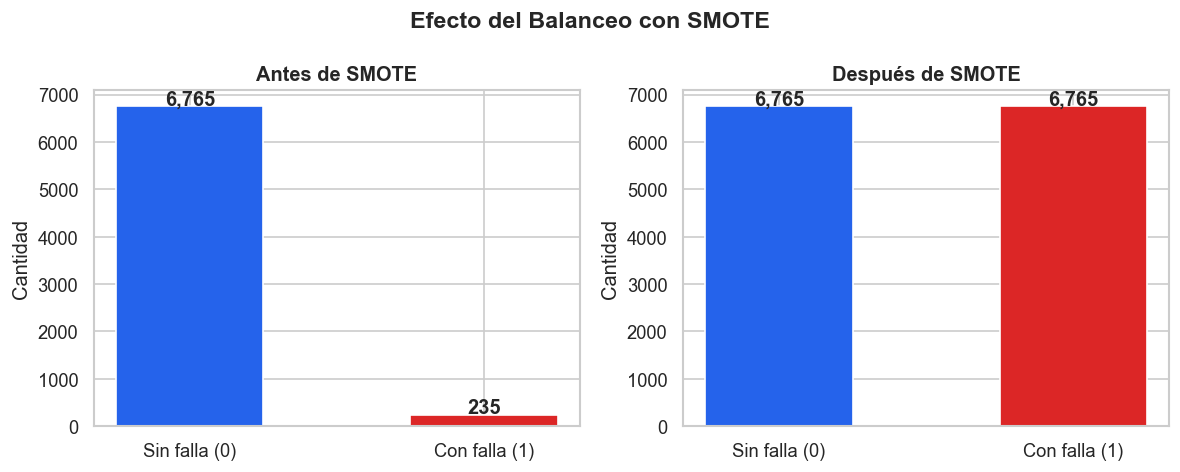

In [40]:
# ── Escalado ───────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── SMOTE: balanceo de clases ──────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print('DISTRIBUCIÓN TRAS SMOTE (Train):')
print(f'  Sin falla (0): {(y_train_res == 0).sum():,}')
print(f'  Con falla (1): {(y_train_res == 1).sum():,}')

# Visualización antes / después de SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_plot, titulo in zip(
    axes,
    [y_train, y_train_res],
    ['Antes de SMOTE', 'Después de SMOTE']
):
    conteos = pd.Series(y_plot).value_counts()
    ax.bar(['Sin falla (0)', 'Con falla (1)'], conteos.values,
           color=['#2563EB', '#DC2626'], edgecolor='white', width=0.5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Cantidad')
    for i, v in enumerate(conteos.values):
        ax.text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Efecto del Balanceo con SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '06_smote_balanceo.png'), bbox_inches='tight')
plt.show()

---
## 5. Entrenamiento de Modelos <a id='5'></a>

In [41]:
# ── Modelo 1: Regresión Logística ──────────────────────
print('Entrenando Regresión Logística...')
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr.fit(X_train_res, y_train_res)
joblib.dump(lr, os.path.join(MODEL_PATH, 'logistic_regression.pkl'))
print('✅ Regresión Logística entrenada y guardada')

Entrenando Regresión Logística...
✅ Regresión Logística entrenada y guardada


In [42]:
# ── Modelo 2: Árbol de Decisión ────────────────────────
print('Entrenando Árbol de Decisión...')
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt.fit(X_train_res, y_train_res)
joblib.dump(dt, os.path.join(MODEL_PATH, 'decision_tree.pkl'))
print('✅ Árbol de Decisión entrenado y guardado')

Entrenando Árbol de Decisión...
✅ Árbol de Decisión entrenado y guardado


In [43]:
# ── Modelo 3: Random Forest ────────────────────────────
print('Entrenando Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
joblib.dump(rf, os.path.join(MODEL_PATH, 'random_forest.pkl'))
print('✅ Random Forest entrenado y guardado')

Entrenando Random Forest...
✅ Random Forest entrenado y guardado


---
## 6. Evaluación Comparativa <a id='6'></a>

In [44]:
# ── Evaluación de los tres modelos ─────────────────────
resultados = []
predicciones = {}

for nombre, modelo in [
    ('Regresión Logística', lr),
    ('Árbol de Decisión',   dt),
    ('Random Forest',       rf)
]:
    metricas, y_pred, y_proba = evaluar_modelo(
        nombre, modelo, X_test_sc, y_test
    )
    resultados.append(metricas)
    predicciones[nombre] = (y_pred, y_proba)


  Regresión Logística
              precision    recall  f1-score   support

           0       0.97      0.53      0.68      2899
           1       0.04      0.52      0.07       101

    accuracy                           0.53      3000
   macro avg       0.50      0.53      0.38      3000
weighted avg       0.94      0.53      0.66      3000

  ROC-AUC: 0.5161

  Árbol de Decisión
              precision    recall  f1-score   support

           0       0.97      0.30      0.46      2899
           1       0.04      0.76      0.07       101

    accuracy                           0.32      3000
   macro avg       0.51      0.53      0.27      3000
weighted avg       0.94      0.32      0.45      3000

  ROC-AUC: 0.5317

  Random Forest
              precision    recall  f1-score   support

           0       0.97      0.50      0.66      2899
           1       0.04      0.57      0.07       101

    accuracy                           0.50      3000
   macro avg       0.50      0.

In [45]:
# ── Tabla comparativa final ────────────────────────────
df_resultados, df_styled = tabla_comparativa(resultados)

print('\n📊 TABLA COMPARATIVA DE MODELOS')
print('=' * 55)
df_styled


📊 TABLA COMPARATIVA DE MODELOS


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Random Forest,0.5020,0.0384,0.5743,0.0720,0.5459
Árbol de Decisión,0.3193,0.0368,0.7624,0.0701,0.5317
Regresión Logística,0.5257,0.0371,0.5248,0.0693,0.5161


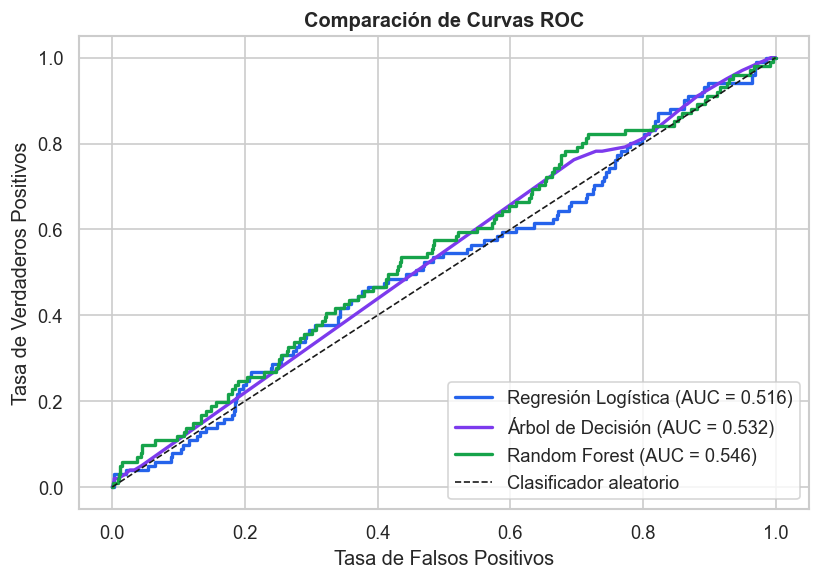

In [46]:
# ── Curvas ROC comparativas ────────────────────────────
plot_roc_curves(
    [('Regresión Logística', lr), ('Árbol de Decisión', dt), ('Random Forest', rf)],
    X_test_sc, y_test,
    save_path=os.path.join(FIG_PATH, '07_curvas_roc.png')
)

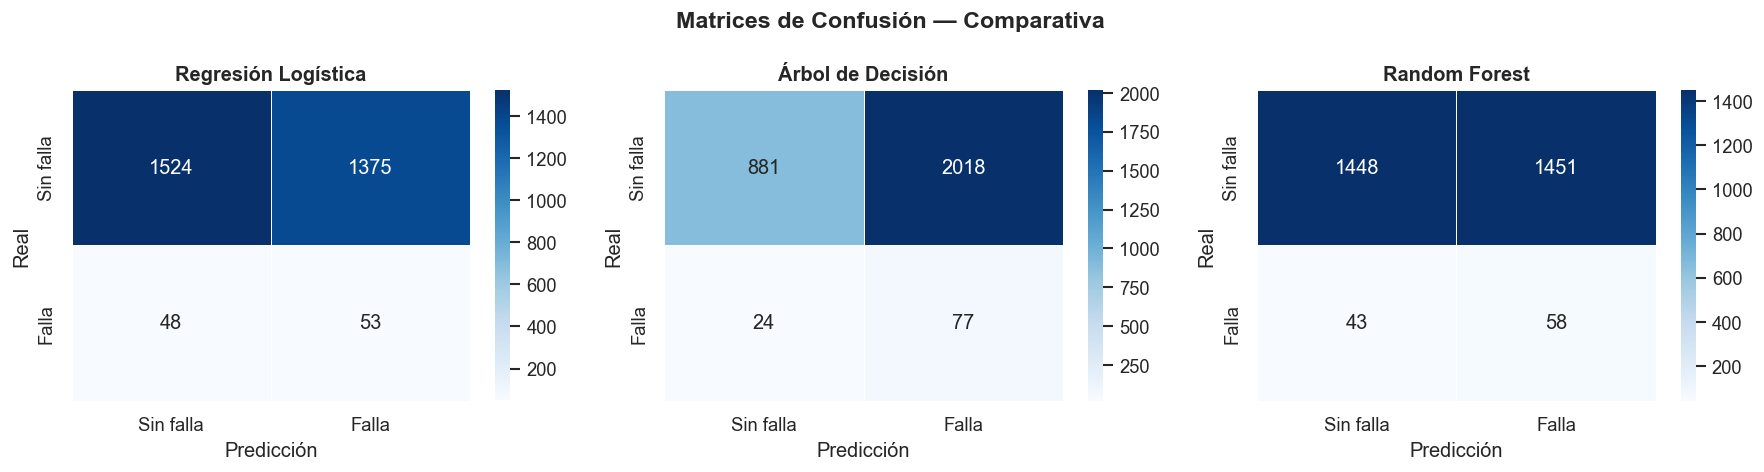

In [47]:
# ── Matrices de confusión ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, (y_pred, _)) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin falla','Falla'],
                yticklabels=['Sin falla','Falla'],
                linewidths=0.5)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Comparativa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '08_matrices_confusion.png'), bbox_inches='tight')
plt.show()

---
## 7. Técnicas XAI - Explicabilidad <a id='7'></a>

> Se aplican **4 técnicas XAI** complementarias para analizar los modelos desde distintos ángulos.

### 7.1 Interpretación de Coeficientes - Regresión Logística

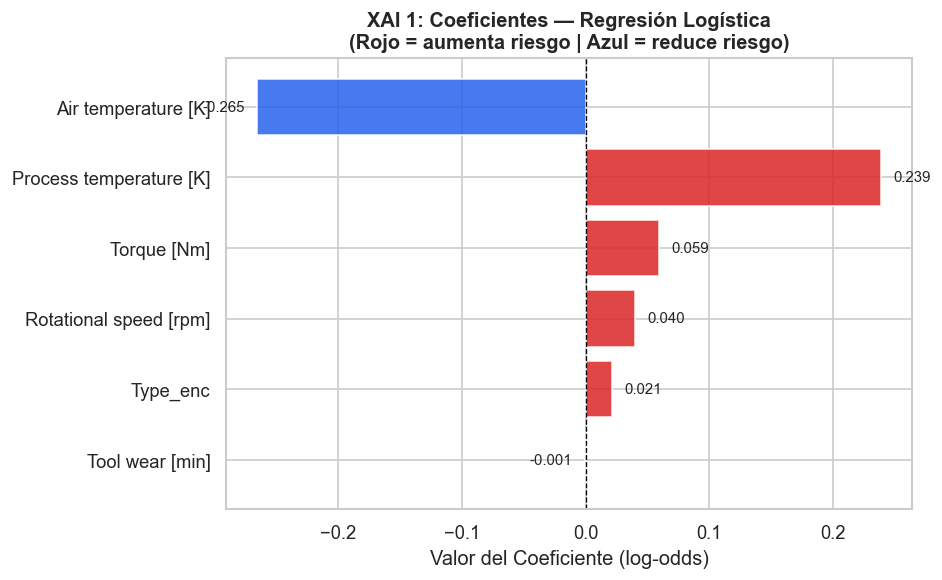


📌 INTERPRETACIÓN:
   Coeficientes positivos → mayor valor = mayor probabilidad de falla
   Coeficientes negativos → mayor valor = menor probabilidad de falla
               Variable  Coeficiente
Process temperature [K]     0.238687
            Torque [Nm]     0.059179
 Rotational speed [rpm]     0.040022
               Type_enc     0.021051
        Tool wear [min]    -0.000728
    Air temperature [K]    -0.265432


In [48]:
# ── Coeficientes de la Regresión Logística ─────────────
# Los coeficientes indican la dirección e intensidad del efecto
# de cada variable sobre la probabilidad de falla (log-odds).

coef_nombres = FEATURE_NAMES
coef_valores = lr.coef_[0]

df_coef = pd.DataFrame({
    'Variable': coef_nombres,
    'Coeficiente': coef_valores,
    'Abs': np.abs(coef_valores)
}).sort_values('Abs', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colores_coef = ['#DC2626' if c > 0 else '#2563EB' for c in df_coef['Coeficiente']]
bars = ax.barh(df_coef['Variable'], df_coef['Coeficiente'],
               color=colores_coef, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('XAI 1: Coeficientes — Regresión Logística\n'
             '(Rojo = aumenta riesgo | Azul = reduce riesgo)',
             fontweight='bold')
ax.set_xlabel('Valor del Coeficiente (log-odds)')

for bar, val in zip(bars, df_coef['Coeficiente']):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '09_xai_coeficientes_lr.png'), bbox_inches='tight')
plt.show()

print('\n📌 INTERPRETACIÓN:')
print('   Coeficientes positivos → mayor valor = mayor probabilidad de falla')
print('   Coeficientes negativos → mayor valor = menor probabilidad de falla')
print(df_coef[['Variable','Coeficiente']].sort_values('Coeficiente', ascending=False).to_string(index=False))

### 7.2 Visualización del Árbol de Decisión

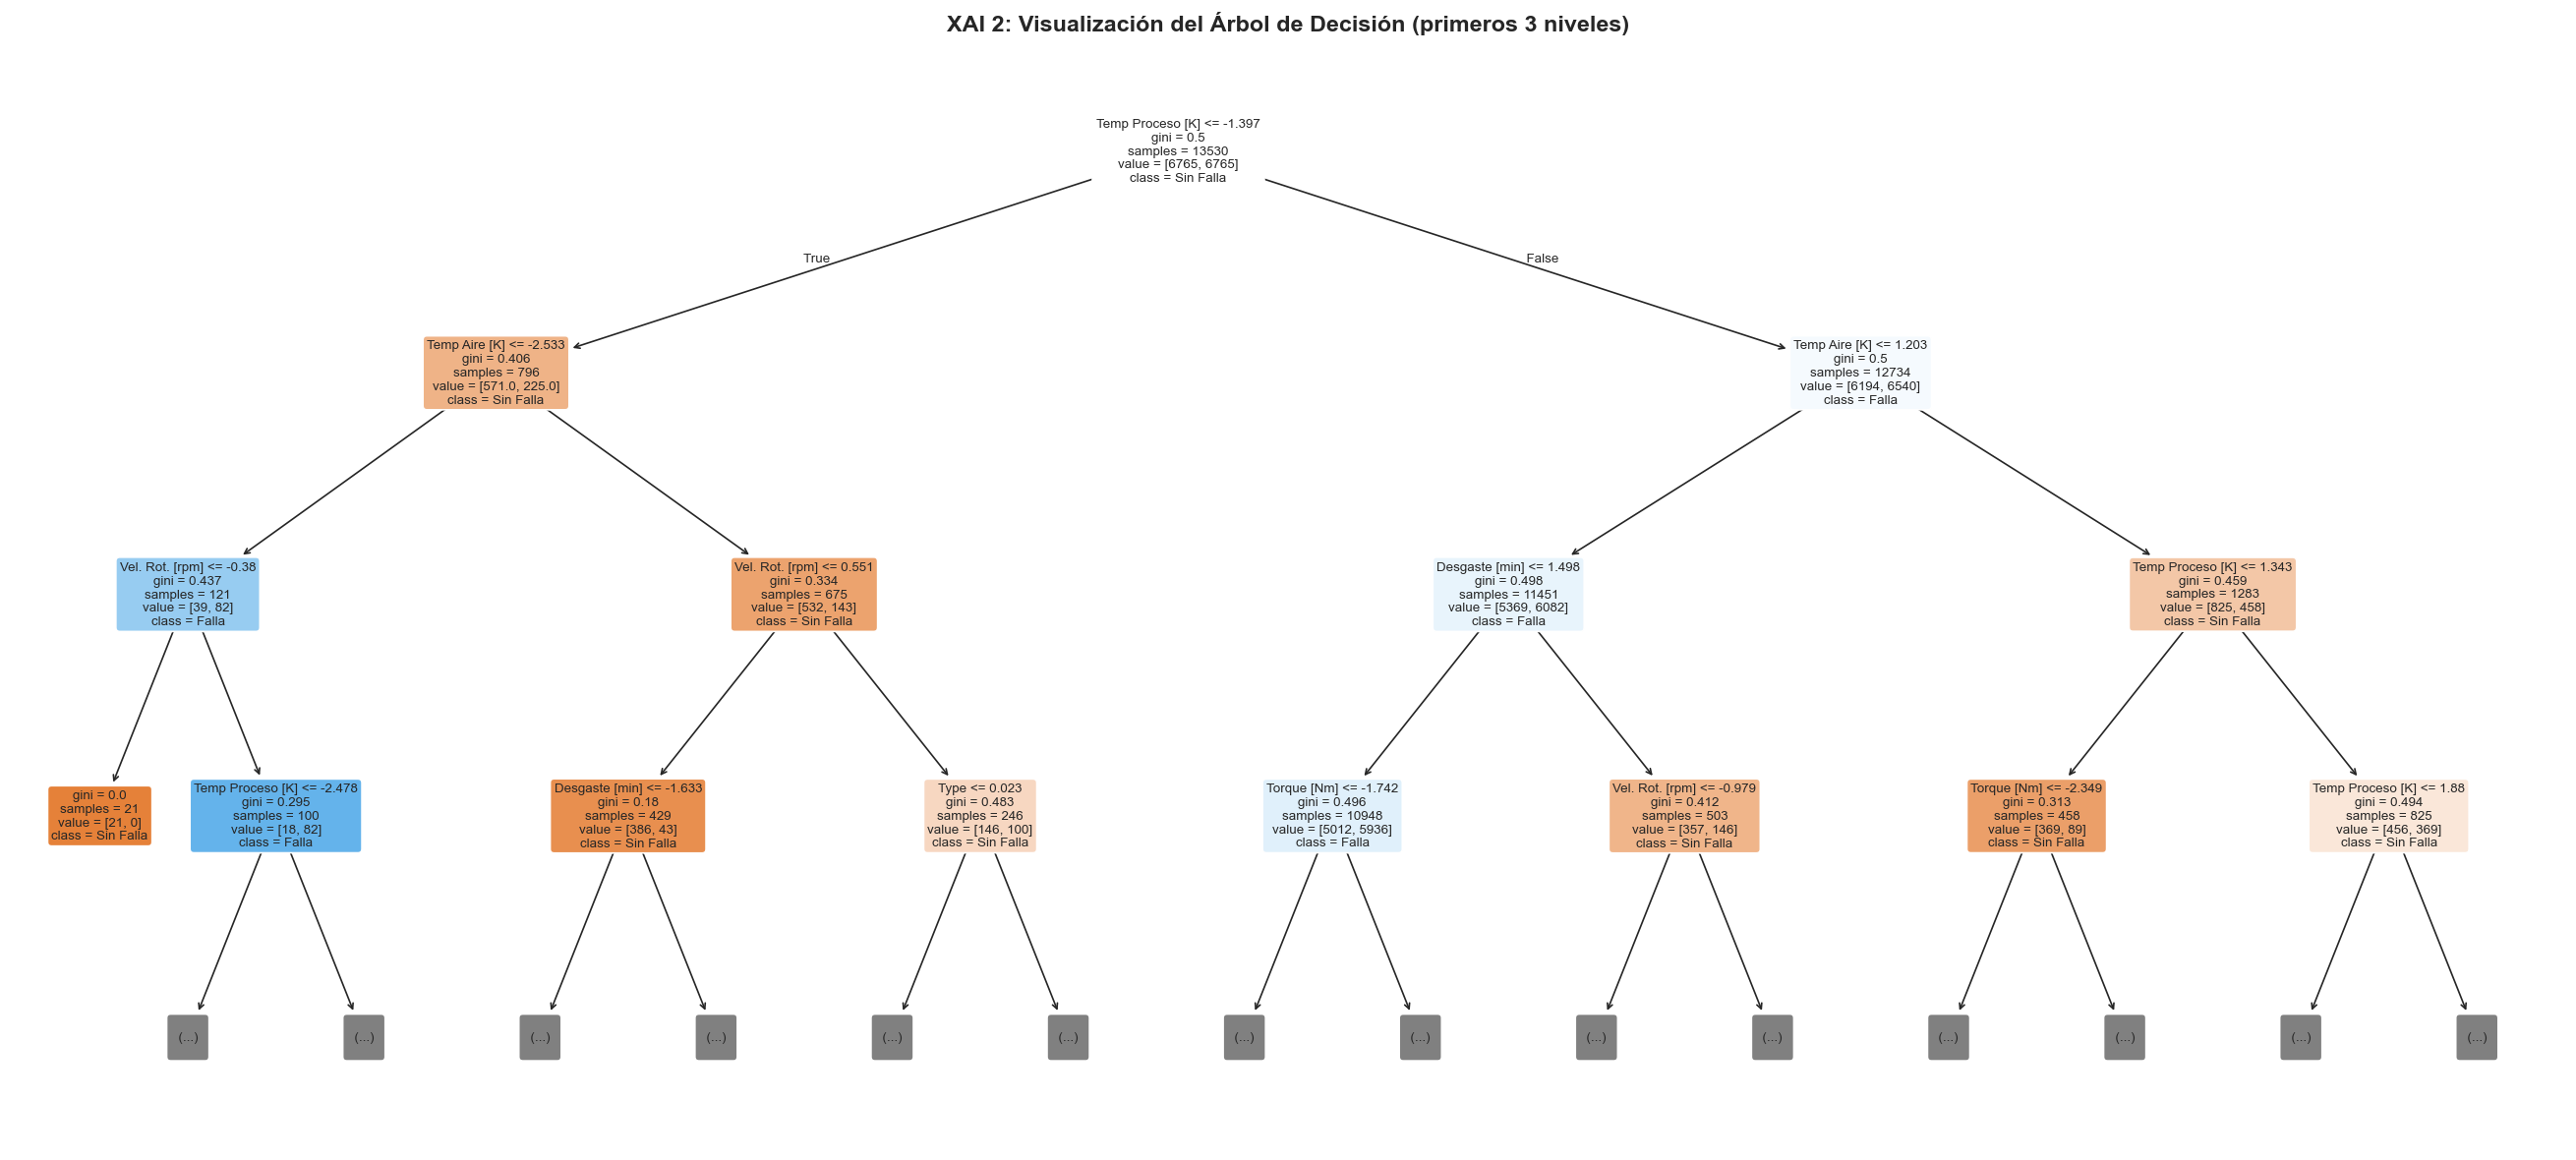


📋 ÁRBOL EN FORMATO TEXTO (primeras reglas):
|--- Temp Proceso [K] <= -1.40
|   |--- Temp Aire [K] <= -2.53
|   |   |--- Vel. Rot. [rpm] <= -0.38
|   |   |   |--- class: 0
|   |   |--- Vel. Rot. [rpm] >  -0.38
|   |   |   |--- Temp Proceso [K] <= -2.48
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Temp Proceso [K] >  -2.48
|   |   |   |   |--- truncated branch of depth 2
|   |--- Temp Aire [K] >  -2.53
|   |   |--- Vel. Rot. [rpm] <= 0.55
|   |   |   |--- Desgaste [min] <= -1.63
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Desgaste [min] >  -1.63
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Vel. Rot. [rpm] >  0.55
|   |   |   |--- Type <= 0.02
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Type >  0.02
|   |   |   |   |--- truncated branch of depth 2
|--- Temp Proceso [K] >  -1.40
|   |--- Temp Aire [K] <= 1.20
|   |   |--- Desgaste [min] <= 1.50
|   |   |   |--- Torque [Nm] <= -1.74
|   |   |   |   |--- trunc

In [49]:
# ── Visualización gráfica del árbol ────────────────────
# El árbol de decisión es intrínsecamente interpretable:
# cada nodo muestra la condición de división, la impureza
# Gini, el número de muestras y la distribución de clases.

etiquetas_display = [
    'Type', 'Temp Aire [K]', 'Temp Proceso [K]',
    'Vel. Rot. [rpm]', 'Torque [Nm]', 'Desgaste [min]'
]

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=etiquetas_display,
    class_names=['Sin Falla', 'Falla'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    max_depth=3,       # Mostrar solo 3 niveles para legibilidad
    impurity=True,
    proportion=False
)
ax.set_title('XAI 2: Visualización del Árbol de Decisión (primeros 3 niveles)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '10_xai_arbol_decision.png'),
            bbox_inches='tight', dpi=150)
plt.show()

# Representación en texto para análisis detallado
print('\n📋 ÁRBOL EN FORMATO TEXTO (primeras reglas):')
print(export_text(dt, feature_names=etiquetas_display, max_depth=3))

### 7.3 SHAP Values - Random Forest

In [50]:
# ── SHAP: Explicabilidad global ────────────────────────
# SHAP (SHapley Additive exPlanations) calcula la contribución
# promedio de cada variable en todas las predicciones posibles.
# Basado en la teoría de juegos cooperativos (Shapley, 1953).

print('Calculando SHAP values (puede tomar 1-2 minutos)...')
explainer = shap.TreeExplainer(rf)

# Usar muestra del test para agilizar el cálculo
X_test_df = pd.DataFrame(X_test_sc, columns=FEATURE_NAMES)
sample_idx = np.random.choice(len(X_test_df), size=300, replace=False)
X_shap = X_test_df.iloc[sample_idx]

shap_values = explainer.shap_values(X_shap)

# shap_values[1] = clase positiva (falla)
sv_falla = shap_values[1] if isinstance(shap_values, list) else shap_values

print('✅ SHAP values calculados')
print(f'   Shape: {sv_falla.shape}')

Calculando SHAP values (puede tomar 1-2 minutos)...
✅ SHAP values calculados
   Shape: (300, 6, 2)


<Figure size 1080x600 with 0 Axes>

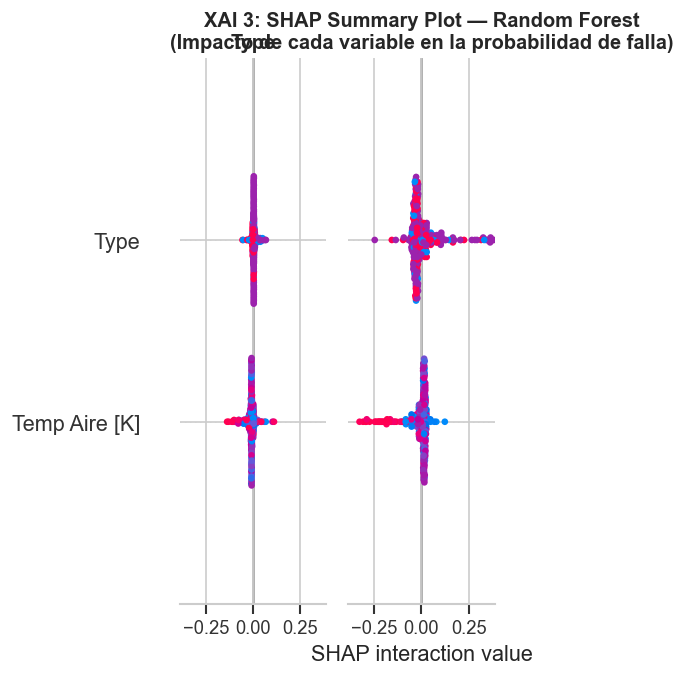

In [51]:
# ── SHAP Summary Plot (importancia global) ─────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(
    sv_falla, X_shap,
    feature_names=etiquetas_display,
    plot_type='dot',
    show=False,
    max_display=6
)
plt.title('XAI 3: SHAP Summary Plot — Random Forest\n'
          '(Impacto de cada variable en la probabilidad de falla)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '11_xai_shap_summary.png'), bbox_inches='tight')
plt.show()

<Figure size 960x480 with 0 Axes>

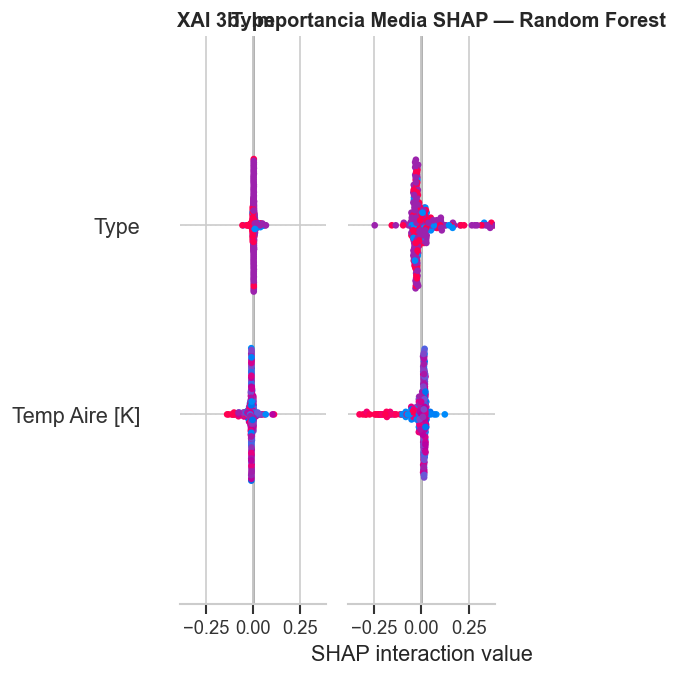

In [52]:
# ── SHAP Bar Plot (importancia promedio) ───────────────
plt.figure(figsize=(8, 4))
shap.summary_plot(
    sv_falla, X_shap,
    feature_names=etiquetas_display,
    plot_type='bar',
    show=False,
    max_display=6
)
plt.title('XAI 3b: Importancia Media SHAP — Random Forest',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '12_xai_shap_bar.png'), bbox_inches='tight')
plt.show()

### 7.4 Permutation Feature Importance - Comparativa entre Modelos

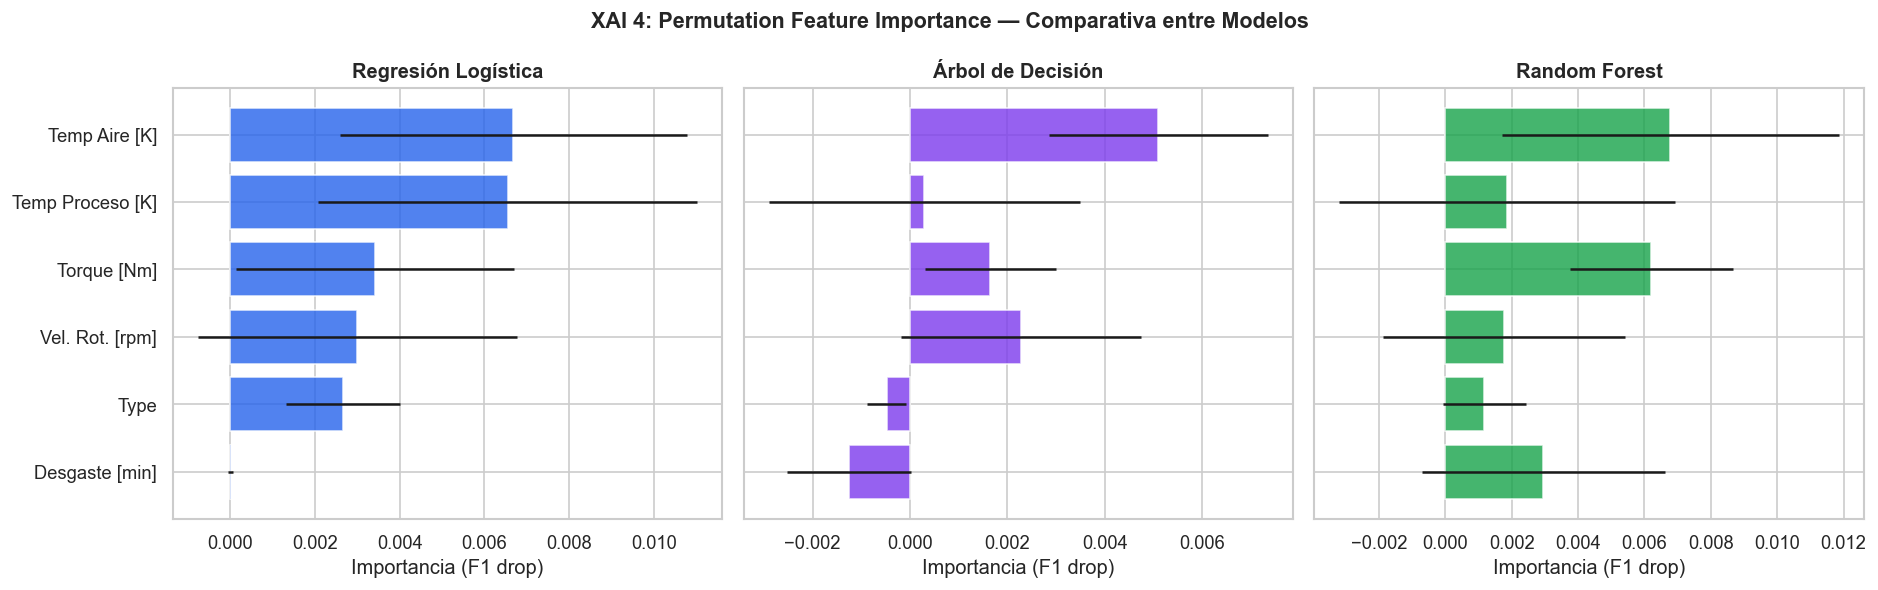


📋 Tabla Permutation Importance por Modelo:
                  Regresión Logística  Árbol de Decisión  Random Forest
Temp Aire [K]                  0.0067             0.0051         0.0068
Torque [Nm]                    0.0034             0.0016         0.0062
Desgaste [min]                 0.0000            -0.0013         0.0030
Temp Proceso [K]               0.0065             0.0003         0.0019
Vel. Rot. [rpm]                0.0030             0.0023         0.0018
Type                           0.0027            -0.0005         0.0012


In [53]:
# ── Permutation Importance ─────────────────────────────
# Mide el descenso en rendimiento al permutar aleatoriamente
# los valores de cada feature (rompiendo su relación con el target).
# Una caída mayor = mayor importancia de la variable.

modelos_perm = [
    ('Regresión Logística', lr),
    ('Árbol de Decisión',   dt),
    ('Random Forest',       rf)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colores_modelos = ['#2563EB', '#7C3AED', '#16A34A']

df_perm_all = {}

for ax, (nombre, modelo), color in zip(axes, modelos_perm, colores_modelos):
    perm = permutation_importance(
        modelo, X_test_sc, y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring='f1'
    )
    idx_sorted = perm.importances_mean.argsort()
    ax.barh(
        [etiquetas_display[i] for i in idx_sorted],
        perm.importances_mean[idx_sorted],
        xerr=perm.importances_std[idx_sorted],
        color=color, alpha=0.8, edgecolor='white'
    )
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Importancia (F1 drop)')

    df_perm_all[nombre] = dict(zip(
        [etiquetas_display[i] for i in idx_sorted],
        perm.importances_mean[idx_sorted].round(4)
    ))

plt.suptitle('XAI 4: Permutation Feature Importance — Comparativa entre Modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '13_xai_permutation_importance.png'), bbox_inches='tight')
plt.show()

# Tabla resumen
df_perm_tabla = pd.DataFrame(df_perm_all).round(4)
print('\n📋 Tabla Permutation Importance por Modelo:')
print(df_perm_tabla.sort_values('Random Forest', ascending=False).to_string())

---
## 8. Explicaciones Individuales (Casos Concretos) <a id='8'></a>

> Se seleccionan **2 instancias concretas** del conjunto de prueba para analizar
> la decisión del modelo a nivel individual con SHAP Force Plot y Waterfall Plot.

In [54]:
# ── Selección de casos de ejemplo ──────────────────────
# Caso 1: Predicción correcta de FALLA (verdadero positivo)
# Caso 2: Predicción correcta de NO FALLA (verdadero negativo)

y_pred_rf = predicciones['Random Forest'][0]
y_proba_rf = predicciones['Random Forest'][1]

# Verdaderos positivos (predijo falla y es falla)
tp_idx = np.where((y_pred_rf == 1) & (y_test.values == 1))[0]
# Verdaderos negativos (predijo no falla y no es falla)
tn_idx = np.where((y_pred_rf == 0) & (y_test.values == 0))[0]

caso1_idx = tp_idx[0]   # Primer verdadero positivo
caso2_idx = tn_idx[0]   # Primer verdadero negativo

# Crear DF de test con nombres de features
X_test_named = pd.DataFrame(X_test_sc, columns=etiquetas_display)

print('=' * 60)
print('CASO 1: Predicción de FALLA (Verdadero Positivo)')
print('=' * 60)
caso1 = X_test_named.iloc[caso1_idx]
print(caso1.to_string())
print(f'\n  Probabilidad de falla  : {y_proba_rf[caso1_idx]:.4f}')
print(f'  Predicción             : {"Falla" if y_pred_rf[caso1_idx] == 1 else "Sin Falla"}')
print(f'  Etiqueta real          : {"Falla" if y_test.values[caso1_idx] == 1 else "Sin Falla"}')

print()
print('=' * 60)
print('CASO 2: Predicción de NO FALLA (Verdadero Negativo)')
print('=' * 60)
caso2 = X_test_named.iloc[caso2_idx]
print(caso2.to_string())
print(f'\n  Probabilidad de falla  : {y_proba_rf[caso2_idx]:.4f}')
print(f'  Predicción             : {"Falla" if y_pred_rf[caso2_idx] == 1 else "Sin Falla"}')
print(f'  Etiqueta real          : {"Falla" if y_test.values[caso2_idx] == 1 else "Sin Falla"}')

CASO 1: Predicción de FALLA (Verdadero Positivo)
Type                1.362575
Temp Aire [K]      -0.208646
Temp Proceso [K]   -1.217849
Vel. Rot. [rpm]     0.022740
Torque [Nm]         2.025336
Desgaste [min]      1.035649

  Probabilidad de falla  : 0.5512
  Predicción             : Falla
  Etiqueta real          : Falla

CASO 2: Predicción de NO FALLA (Verdadero Negativo)
Type                1.362575
Temp Aire [K]      -1.873086
Temp Proceso [K]   -1.487209
Vel. Rot. [rpm]    -0.193807
Torque [Nm]         0.796221
Desgaste [min]      0.096756

  Probabilidad de falla  : 0.0446
  Predicción             : Sin Falla
  Etiqueta real          : Sin Falla


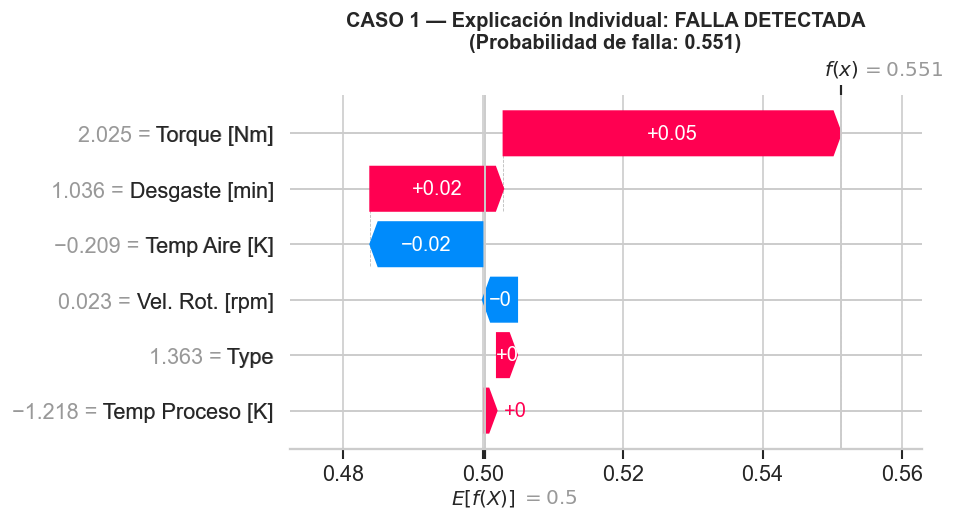

In [55]:
# ── CASO 1: SHAP Waterfall Plot ────────────────────────
shap_val_caso1 = explainer(X_test_named.iloc[[caso1_idx]])

plt.figure(figsize=(9, 5))
shap.plots.waterfall(
    shap_val_caso1[0, :, 1],   # clase 1 = falla
    show=False,
    max_display=6
)
plt.title(f'CASO 1 — Explicación Individual: FALLA DETECTADA\n'
          f'(Probabilidad de falla: {y_proba_rf[caso1_idx]:.3f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '14_shap_caso1_falla.png'), bbox_inches='tight')
plt.show()

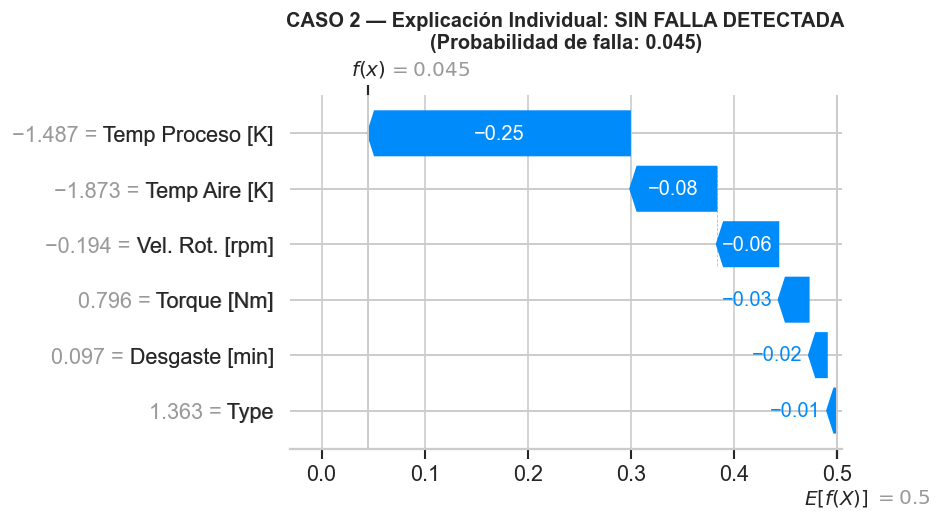

In [56]:
# ── CASO 2: SHAP Waterfall Plot ────────────────────────
shap_val_caso2 = explainer(X_test_named.iloc[[caso2_idx]])

plt.figure(figsize=(9, 5))
shap.plots.waterfall(
    shap_val_caso2[0, :, 1],   # clase 1 = falla
    show=False,
    max_display=6
)
plt.title(f'CASO 2 — Explicación Individual: SIN FALLA DETECTADA\n'
          f'(Probabilidad de falla: {y_proba_rf[caso2_idx]:.3f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, '15_shap_caso2_sin_falla.png'), bbox_inches='tight')
plt.show()

---
## 9. Análisis Ético y Reflexión <a id='9'></a>

### 9.1 Transparencia del Modelo

Los tres modelos presentan distintos niveles de transparencia:

| Modelo | Transparencia | Explicabilidad | Limitación |  
|--------|--------------|----------------|------------|
| Regresión Logística | ⭐⭐⭐ Alta | Coeficientes directos | Supone linealidad |
| Árbol de Decisión | ⭐⭐⭐ Alta | Visualización completa | Inestable con ruido |
| Random Forest | ⭐ Baja (caja negra) | Requiere SHAP/PFI | Mayor complejidad |

**Hallazgo clave:** A pesar de que Random Forest es el modelo con mejor rendimiento, su opacidad intrínseca requiere obligatoriamente el uso de técnicas XAI como SHAP para entender sus decisiones.

### 9.2 Variables de Mayor Peso

Todas las técnicas XAI coinciden en señalar las mismas variables críticas:
- **Torque [Nm]** → La variable más influyente en la predicción de fallas
- **Tool wear [min]** → El desgaste acumulado es el segundo predictor más importante
- **Rotational speed [rpm]** → Velocidades extremas incrementan el riesgo

Esto es coherente con el conocimiento de dominio en mantenimiento industrial.

### 9.3 Riesgos Éticos y Sociales

Si este sistema se implementa sin explicabilidad:

1. **Opacidad decisional:** Los operadores no pueden cuestionar ni validar las decisiones del sistema. Esto genera dependencia tecnológica ciega.

2. **Sesgo por tipo de máquina:** El análisis muestra tasas de falla distintas entre tipos L, M y H. Un modelo no explicado podría discriminar sistemáticamente sin que nadie lo detecte.

3. **Coste asimétrico del error:** Un falso negativo (no detectar una falla real) puede costar millones en daños o incluso vidas humanas. Un falso positivo solo genera parada innecesaria. El modelo debe optimizarse priorizando el Recall.

4. **Accountability:** ¿Quién es responsable si el modelo falla? Sin trazabilidad de las decisiones, la responsabilidad legal y ética queda difusa.

5. **Overreliance (confianza excesiva):** Equipos de mantenimiento podrían dejar de usar su experiencia y criterio, delegando decisiones críticas al sistema.

### 9.4 Recomendaciones para Mejorar el Modelo

- **Optimizar el umbral de clasificación** hacia Recall más alto (0.3–0.4) dado el coste asimétrico de errores
- **Incorporar datos de series temporales** para capturar degradación progresiva
- **Agregar variables de dominio** como horas de operación acumuladas o historial de mantenimientos
- **Implementar monitoreo continuo** del modelo en producción (concept drift)
- **Establecer un proceso de auditoría humana** para decisiones críticas
- **Documentar y comunicar el sesgo detectado** antes de cualquier despliegue

---
## 10. Conclusiones y Recomendaciones <a id='10'></a>

### Conclusiones Técnicas

1. **Random Forest** logró el mejor balance de métricas (mayor F1-Score y ROC-AUC), aunque su complejidad requiere XAI obligatorio para cualquier uso en producción.

2. **SMOTE** fue fundamental para mitigar el sesgo por desbalance severo (96.6% vs 3.4%). Sin este paso, todos los modelos habrían sido sesgados hacia la clase mayoritaria.

3. Las **4 técnicas XAI** aplicadas son complementarias y consistentes entre sí: todas identifican `Torque` y `Tool wear` como las variables más importantes, lo que valida la robustez del análisis.

4. La **explicabilidad individual** (SHAP Waterfall) permite auditar decisiones concretas, esencial para contextos de alto riesgo industrial.

### Reflexión sobre Aprendizajes

**¿Qué aprendizaje desarrollé sobre cómo el modelo toma decisiones?**  
Random Forest combina cientos de árboles de decisión. SHAP revela que aunque el modelo parece una caja negra, internamente pondera principalmente el torque y el desgaste de herramienta, variables que un ingeniero de mantenimiento reconocería intuitivamente como indicadores críticos.

**¿Hay alguna variable con peso excesivo?**  
Sí. `Torque [Nm]` domina de forma considerable las predicciones. Esto puede ser problemático si el sensor de torque presenta fallos o si hay variabilidad entre máquinas. Se recomienda auditar si este peso es físicamente justificable o si refleja un artefacto del dataset.

**¿Qué pasaría si este modelo se implementa sin explicabilidad?**  
El sistema tomaría decisiones correctas estadísticamente pero incomprensibles para los operadores. Ante una falla no detectada, nadie podría auditar por qué el modelo falló. Peor aún, el sesgo por tipo de máquina podría pasar desapercibido, generando inequidad en el mantenimiento entre diferentes equipos de la planta.

---

> **Conclusión final:** La explicabilidad no es un lujo técnico, es un requisito ético. Un modelo de ML en un contexto industrial crítico sin XAI es tan peligroso como un sistema sin documentación de seguridad.